---
##  Étape 1: Imports et Setup

In [1]:
# Imports nécessaires
import sys
from pathlib import Path

# Forcer explicitement la racine du projet (celle qui contient `src/`)
# Adapté à ta machine: C:\Users\roche\LCS_Transformers
project_root = Path.home() / "LCS_Transformers"
print(f"[INFO] Racine projet forcée: {project_root}")

# Ajouter le chemin du projet au PYTHONPATH
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Nos modules
from src.examples.toy_seq2seq import (
    SignalDataset,
    SimpleSignalTransformer,
    collate_fn,
    train_epoch,
    evaluate
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')

[INFO] Racine projet forcée: C:\Users\roche\LCS_Transformers
 Device: cpu


---
##  Étape 2: Comprendre les Données

### 2.1 Création du Dataset

Le dataset génère des paires (input, output) où:
- **Input**: Signal avec 4 pics (2 triangles, 2 carrés) de hauteurs différentes
- **Output**: Signal avec pics MOYENNÉS par type

In [2]:
# Créer un petit dataset pour exploration
dataset = SignalDataset(
    num_samples=100,      # 100 exemples
    seq_len=100,          # Signal de 100 points
    num_peaks_per_type=2, # 2 triangles, 2 carrés
    min_height=5.0,       # Hauteur min des pics
    max_height=25.0,      # Hauteur max des pics
    seed=42
)

print(f"Dataset créé: {len(dataset)} échantillons")

Dataset créé: 100 échantillons


### 2.2 Visualiser un exemple

In [3]:
# Récupérer un exemple
input_signal, output_signal, peak_info = dataset[0]

# Afficher les informations
print(" INFORMATIONS SUR L'EXEMPLE:")
print(f"   Shape input: {input_signal.shape}")
print(f"   Shape output: {output_signal.shape}")
print()
print("   PICS TYPE A (Triangles):")
print(f"      Positions: {peak_info['type_a_positions']}")
print(f"      Hauteurs: {[f'{h:.1f}' for h in peak_info['type_a_heights']]}")
print(f"      → Moyenne: {peak_info['avg_a']:.2f}")
print()
print("   PICS TYPE B (Carrés):")
print(f"      Positions: {peak_info['type_b_positions']}")
print(f"      Hauteurs: {[f'{h:.1f}' for h in peak_info['type_b_heights']]}")
print(f"      → Moyenne: {peak_info['avg_b']:.2f}")

 INFORMATIONS SUR L'EXEMPLE:
   Shape input: torch.Size([100])
   Shape output: torch.Size([100])

   PICS TYPE A (Triangles):
      Positions: [27, 82]
      Hauteurs: ['5.5', '6.7']
      → Moyenne: 6.12

   PICS TYPE B (Carrés):
      Positions: [19, 25]
      Hauteurs: ['22.2', '18.2']
      → Moyenne: 20.20


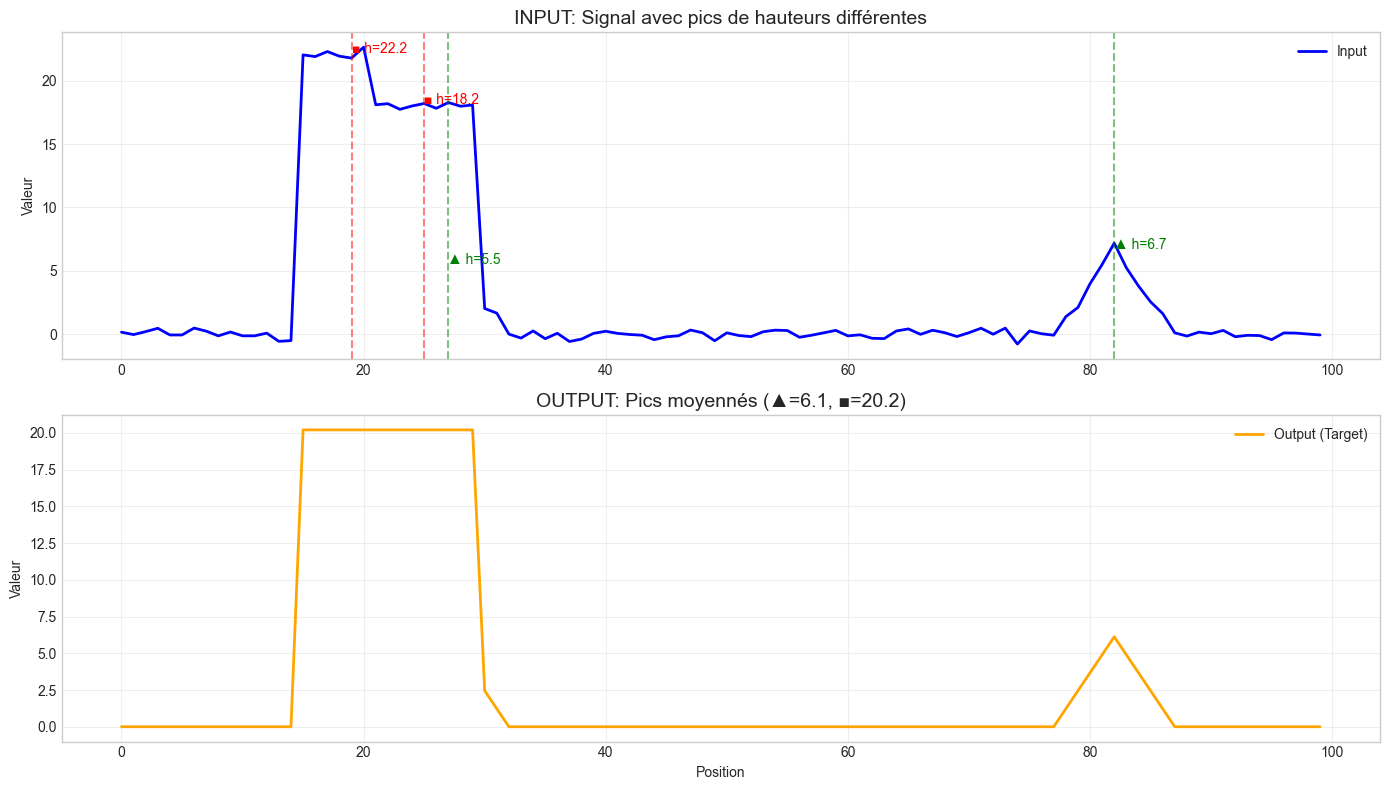


💡 OBSERVATION:
   - Les triangles (▲) ont maintenant TOUS la même hauteur (leur moyenne)
   - Les carrés (■) ont maintenant TOUS la même hauteur (leur moyenne)


In [4]:
# Visualiser l'exemple
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

x = np.arange(len(input_signal))

# Signal Input
ax1 = axes[0]
ax1.plot(x, input_signal.numpy(), 'b-', linewidth=2, label='Input')
ax1.set_title('INPUT: Signal avec pics de hauteurs différentes', fontsize=14)
ax1.set_ylabel('Valeur')

# Marquer les pics
for i, pos in enumerate(peak_info['type_a_positions']):
    ax1.axvline(x=pos, color='green', linestyle='--', alpha=0.5)
    ax1.annotate(f'▲ h={peak_info["type_a_heights"][i]:.1f}', 
                 xy=(pos, peak_info['type_a_heights'][i]), 
                 fontsize=10, color='green')

for i, pos in enumerate(peak_info['type_b_positions']):
    ax1.axvline(x=pos, color='red', linestyle='--', alpha=0.5)
    ax1.annotate(f'■ h={peak_info["type_b_heights"][i]:.1f}', 
                 xy=(pos, peak_info['type_b_heights'][i]), 
                 fontsize=10, color='red')

ax1.legend()
ax1.grid(True, alpha=0.3)

# Signal Output
ax2 = axes[1]
ax2.plot(x, output_signal.numpy(), 'orange', linewidth=2, label='Output (Target)')
ax2.set_title(f'OUTPUT: Pics moyennés (▲={peak_info["avg_a"]:.1f}, ■={peak_info["avg_b"]:.1f})', fontsize=14)
ax2.set_xlabel('Position')
ax2.set_ylabel('Valeur')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 OBSERVATION:")
print("   - Les triangles (▲) ont maintenant TOUS la même hauteur (leur moyenne)")
print("   - Les carrés (■) ont maintenant TOUS la même hauteur (leur moyenne)")

---
## Étape 3: Architecture du Modèle Transformer avec PATCHING

### 3.1 Pourquoi le Patching ? (Important!)

**Approche NAÏVE (à éviter):**
- Chaque point du signal = 1 token
- Signal de 100 points → 100 tokens
- Problème: pas de contexte local, calcul quadratique O(N²)

**Approche PROFESSIONNELLE (patching):**
- On regroupe les points en "patches" (morceaux)
- Avec patch_size=5: 100 points → 20 tokens
- Avantages:
  - Chaque token capture la FORME locale du signal
  - Moins de tokens = moins de calcul d'attention
  - Meilleure généralisation

### 3.2 Créer le modèle

In [5]:
# Créer le modèle AVEC PATCHING
model = SimpleSignalTransformer(
    seq_len=100,      # Longueur des signaux
    d_model=64,       # Dimension des embeddings
    num_heads=4,      # Nombre de têtes d'attention
    d_ff=256,         # Dimension feed-forward
    num_layers=3,     # Nombre de couches encoder
    dropout=0.1,      # Régularisation
    patch_size=5      # NOUVEAU: regroupe 5 points par token
).to(device)

# Afficher l'architecture
print(" ARCHITECTURE DU MODÈLE AVEC PATCHING:")
print(model)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n PARAMÈTRES:")
print(f"   Total: {total_params:,}")
print(f"   Entraînables: {trainable_params:,}")

print(f"\n🔧 CONFIGURATION PATCHING:")
print(f"   Signal: {model.seq_len} points")
print(f"   Patch size: {model.patch_size} points par token")
print(f"   Nombre de tokens: {model.num_patches} (au lieu de {model.seq_len}!)")
print(f"   Réduction: {model.seq_len // model.num_patches}x moins de tokens")

 ARCHITECTURE DU MODÈLE AVEC PATCHING:
SimpleSignalTransformer(
  (input_proj): Linear(in_features=5, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=64, out_features=5, bias=True)
)

 PARAMÈTRES:
   Total: 151,941
   Entraînables: 151,941

🔧 CONFIGURATION PATCHING:
   Signal: 100 poi

### 3.2 Comprendre le flux de données

In [6]:
# Démonstration du flux de données AVEC PATCHING
print(" FLUX DE DONNÉES AVEC PATCHING:")
print("="*60)

batch_size = 1
patch_size = model.patch_size
num_patches = model.num_patches

# Input
x = input_signal.unsqueeze(0).to(device)  # [1, 100]
print(f"\n1. INPUT (signal brut):")
print(f"   Shape: {x.shape}")
print(f"   = {x.shape[1]} points consécutifs")

# Découpage en patches
x_patches = x.view(batch_size, num_patches, patch_size)
print(f"\n2. DÉCOUPAGE EN PATCHES:")
print(f"   Shape: {x_patches.shape}")
print(f"   = {num_patches} patches de {patch_size} points chacun")
print(f"   → Chaque patch capture un MORCEAU du signal (contexte local)")

# Projection
x_proj = model.input_proj(x_patches)
print(f"\n3. PROJECTION (patch_size → d_model):")
print(f"   Shape: {x_proj.shape}")
print(f"   Chaque patch ({patch_size} points) → vecteur de {model.d_model} dimensions")

# Positional encoding
x_pos = x_proj + model.pos_embedding
print(f"\n4. + POSITIONAL ENCODING:")
print(f"   Shape: {x_pos.shape}")
print(f"   Chaque patch sait SA POSITION dans le signal")

# Encoder
x_encoded = model.encoder(x_pos)
print(f"\n5. ENCODER (Self-Attention entre PATCHES):")
print(f"   Shape: {x_encoded.shape}")
print(f"   Les patches peuvent s'observer mutuellement")
print(f"   → Complexité: O({num_patches}²) au lieu de O({model.seq_len}²)!")

# Output projection
x_out = model.output_proj(x_encoded)
print(f"\n6. PROJECTION SORTIE (d_model → patch_size):")
print(f"   Shape: {x_out.shape}")
print(f"   Chaque patch reconstruit {patch_size} points")

# Reconstruction
output = x_out.view(batch_size, model.seq_len)
print(f"\n7. RECONSTRUCTION:")
print(f"   Shape: {output.shape}")
print(f"   Signal complet reconstitué")

print("\n" + "="*60)
print("✅ AVANTAGE DU PATCHING:")
print(f"   Ancien: {model.seq_len} tokens → Attention O({model.seq_len}²) = {model.seq_len**2:,} opérations")
print(f"   Nouveau: {num_patches} tokens → Attention O({num_patches}²) = {num_patches**2:,} opérations")
print(f"   Gain: {model.seq_len**2 // num_patches**2}x moins de calcul!")

 FLUX DE DONNÉES AVEC PATCHING:

1. INPUT (signal brut):
   Shape: torch.Size([1, 100])
   = 100 points consécutifs

2. DÉCOUPAGE EN PATCHES:
   Shape: torch.Size([1, 20, 5])
   = 20 patches de 5 points chacun
   → Chaque patch capture un MORCEAU du signal (contexte local)

3. PROJECTION (patch_size → d_model):
   Shape: torch.Size([1, 20, 64])
   Chaque patch (5 points) → vecteur de 64 dimensions

4. + POSITIONAL ENCODING:
   Shape: torch.Size([1, 20, 64])
   Chaque patch sait SA POSITION dans le signal

5. ENCODER (Self-Attention entre PATCHES):
   Shape: torch.Size([1, 20, 64])
   Les patches peuvent s'observer mutuellement
   → Complexité: O(20²) au lieu de O(100²)!

6. PROJECTION SORTIE (d_model → patch_size):
   Shape: torch.Size([1, 20, 5])
   Chaque patch reconstruit 5 points

7. RECONSTRUCTION:
   Shape: torch.Size([1, 100])
   Signal complet reconstitué

✅ AVANTAGE DU PATCHING:
   Ancien: 100 tokens → Attention O(100²) = 10,000 opérations
   Nouveau: 20 tokens → Attention O(2

### 3.3 Visualiser les prédictions AVANT entraînement

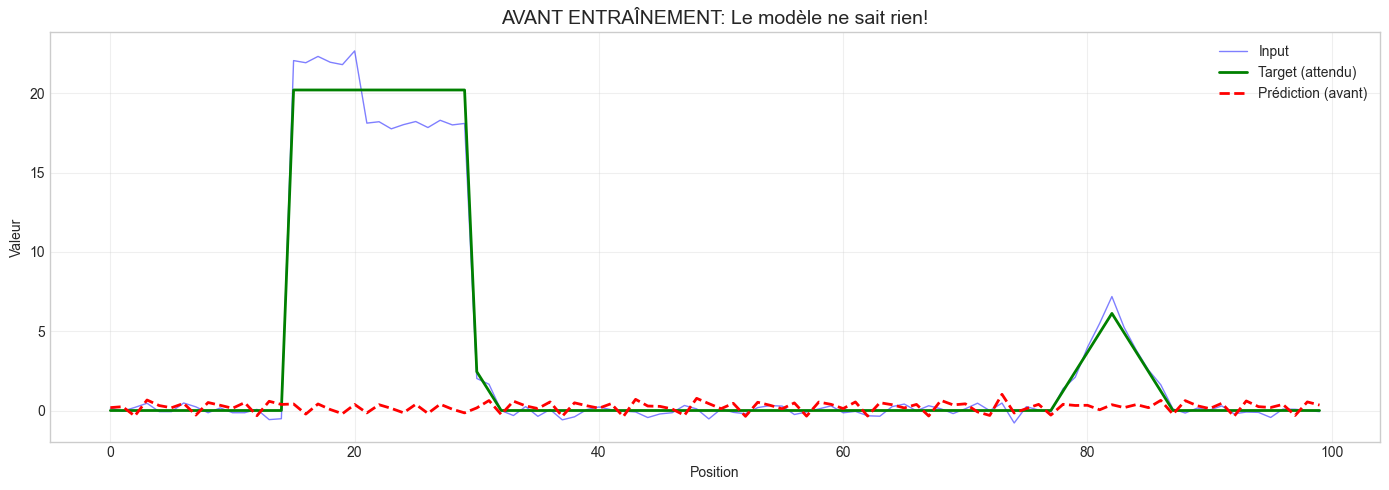


 MSE avant entraînement: 61.88
   → Le modèle prédit n'importe quoi (poids aléatoires)


In [7]:
# Prédiction avant entraînement
model.eval()
with torch.no_grad():
    prediction_before = model(input_signal.unsqueeze(0).to(device)).squeeze(0).cpu()

# Visualiser
fig, ax = plt.subplots(figsize=(14, 5))

x_axis = np.arange(len(input_signal))
ax.plot(x_axis, input_signal.numpy(), 'b-', alpha=0.5, label='Input', linewidth=1)
ax.plot(x_axis, output_signal.numpy(), 'g-', label='Target (attendu)', linewidth=2)
ax.plot(x_axis, prediction_before.numpy(), 'r--', label='Prédiction (avant)', linewidth=2)

ax.set_title('AVANT ENTRAÎNEMENT: Le modèle ne sait rien!', fontsize=14)
ax.set_xlabel('Position')
ax.set_ylabel('Valeur')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mse_before = ((prediction_before - output_signal) ** 2).mean().item()
print(f"\n MSE avant entraînement: {mse_before:.2f}")
print("   → Le modèle prédit n'importe quoi (poids aléatoires)")

---
##  Étape 4: Entraînement du Modèle

### 4.1 Préparer les DataLoaders

In [8]:
# Datasets
train_dataset = SignalDataset(num_samples=1000, seq_len=100, seed=42)
val_dataset = SignalDataset(num_samples=200, seq_len=100, seed=123)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)

print(f" DONNÉES:")
print(f"   Train: {len(train_dataset)} échantillons → {len(train_loader)} batches")
print(f"   Val: {len(val_dataset)} échantillons → {len(val_loader)} batches")

 DONNÉES:
   Train: 1000 échantillons → 32 batches
   Val: 200 échantillons → 7 batches


### 4.2 Configurer l'entraînement

In [9]:
# Recréer le modèle (pour repartir de zéro)
model = SimpleSignalTransformer(
    seq_len=100, d_model=64, num_heads=4, d_ff=256, num_layers=3
).to(device)

# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(" CONFIGURATION:")
print(f"   Loss: MSELoss (mesure la différence au carré)")
print(f"   Optimizer: AdamW (lr=0.001)")
print(f"   Scheduler: CosineAnnealing (décroissance du lr)")

 CONFIGURATION:
   Loss: MSELoss (mesure la différence au carré)
   Optimizer: AdamW (lr=0.001)
   Scheduler: CosineAnnealing (décroissance du lr)


### 4.3 Boucle d'entraînement

In [ ]:
# Entraînement
num_epochs = 30
train_losses = []
val_losses = []

print(" ENTRAÎNEMENT:")
print("="*60)

for epoch in range(1, num_epochs + 1):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    
    # Validation
    val_loss = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Update learning rate
    scheduler.step()
    
    # Affichage
    if epoch % 5 == 0 or epoch == 1:
        bar_len = int((1 - train_loss / train_losses[0]) * 30)
        bar = "█" * max(0, bar_len) + "░" * (30 - max(0, bar_len))
        print(f"   Epoch {epoch:2d}/{num_epochs}: train={train_loss:.4f}, val={val_loss:.4f} [{bar}]")

print("="*60)
print(f"\n Entraînement terminé!")
print(f"   Loss initiale: {train_losses[0]:.4f}")
print(f"   Loss finale: {train_losses[-1]:.4f}")
print(f"   Réduction: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}%")

 ENTRAÎNEMENT:
   Epoch  1/30: train=39.0851, val=30.9005 [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
   Epoch  5/30: train=8.6419, val=6.7353 [███████████████████████░░░░░░░]
   Epoch 10/30: train=3.1516, val=2.5898 [███████████████████████████░░░]
   Epoch 15/30: train=2.1111, val=1.7752 [████████████████████████████░░]
   Epoch 20/30: train=1.6258, val=1.2660 [████████████████████████████░░]
   Epoch 25/30: train=1.4382, val=1.1512 [████████████████████████████░░]
   Epoch 30/30: train=1.4006, val=1.0992 [████████████████████████████░░]

✅ Entraînement terminé!
   Loss initiale: 39.0851
   Loss finale: 1.4006
   Réduction: 96.4%


### 4.4 Visualiser la progression

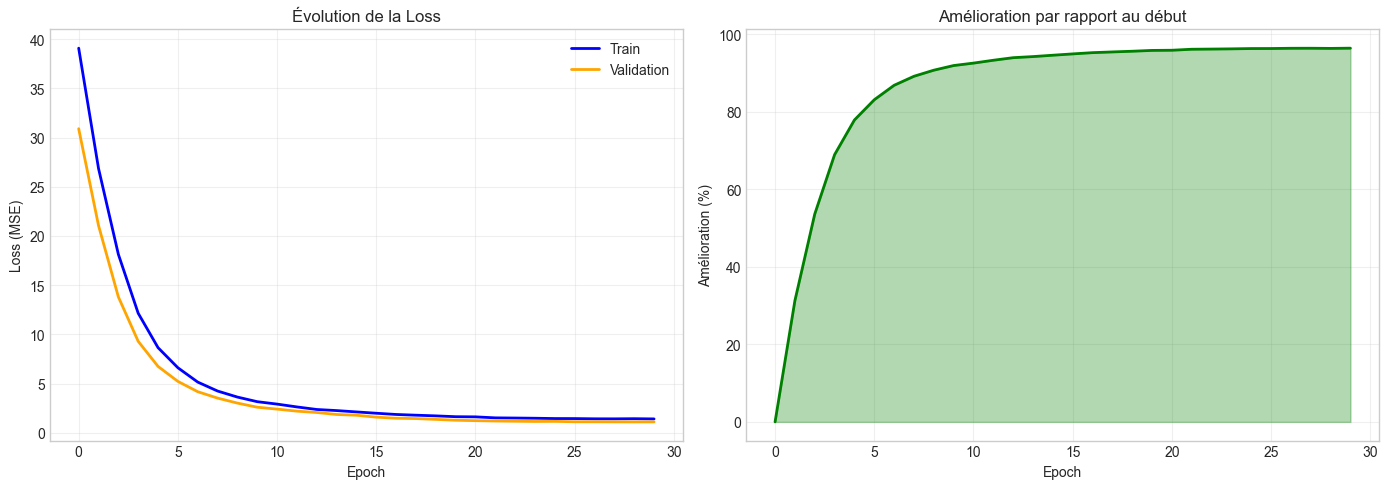

In [11]:
# Courbes de loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1 = axes[0]
ax1.plot(train_losses, 'b-', label='Train', linewidth=2)
ax1.plot(val_losses, 'orange', label='Validation', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Évolution de la Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Amélioration
ax2 = axes[1]
improvements = [(train_losses[0] - l) / train_losses[0] * 100 for l in train_losses]
ax2.fill_between(range(len(improvements)), improvements, alpha=0.3, color='green')
ax2.plot(improvements, 'g-', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Amélioration (%)')
ax2.set_title('Amélioration par rapport au début')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
##  Étape 5: Évaluation et Résultats

### 5.1 Prédictions APRÈS entraînement

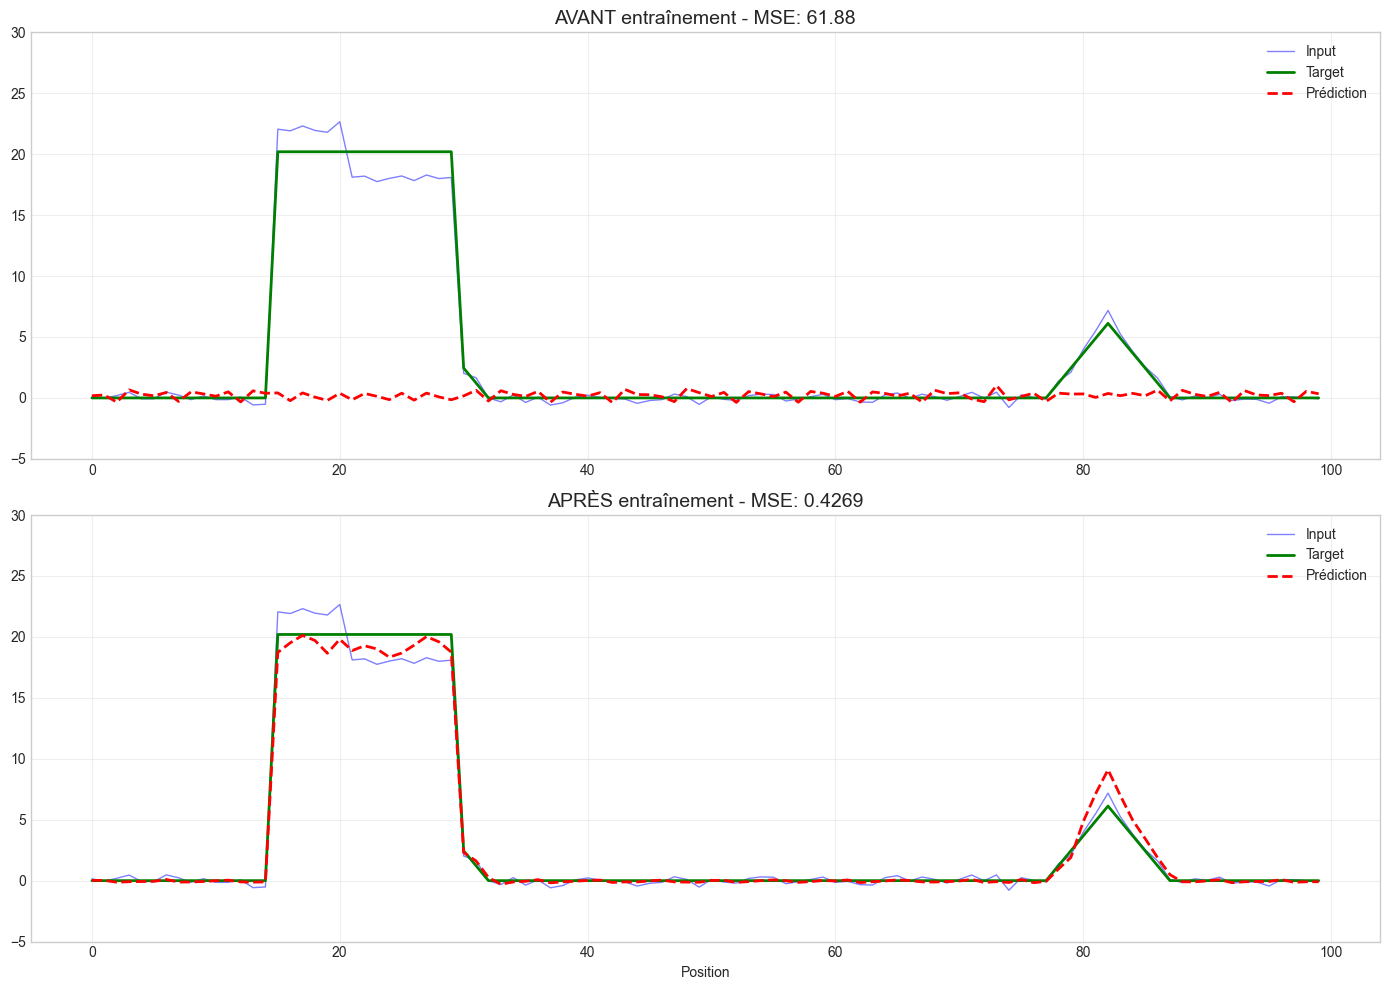


📈 AMÉLIORATION:
   MSE avant: 61.88
   MSE après: 0.4269
   Réduction: 99.3%


In [ ]:
# Prédiction après entraînement
model.eval()
with torch.no_grad():
    prediction_after = model(input_signal.unsqueeze(0).to(device)).squeeze(0).cpu()

# Comparaison AVANT vs APRÈS
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Axe x pour les plots
x_axis = np.arange(len(input_signal))

# AVANT
ax1 = axes[0]
ax1.plot(x_axis, input_signal.numpy(), 'b-', alpha=0.5, label='Input', linewidth=1)
ax1.plot(x_axis, output_signal.numpy(), 'g-', label='Target', linewidth=2)
ax1.plot(x_axis, prediction_before.numpy(), 'r--', label='Prédiction', linewidth=2)
mse_before_val = ((prediction_before - output_signal) ** 2).mean().item()
ax1.set_title(f'AVANT entraînement - MSE: {mse_before_val:.2f}', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-5, 30)

# APRÈS
ax2 = axes[1]
ax2.plot(x_axis, input_signal.numpy(), 'b-', alpha=0.5, label='Input', linewidth=1)
ax2.plot(x_axis, output_signal.numpy(), 'g-', label='Target', linewidth=2)
ax2.plot(x_axis, prediction_after.numpy(), 'r--', label='Prédiction', linewidth=2)
mse_after = ((prediction_after - output_signal) ** 2).mean().item()
ax2.set_title(f'APRÈS entraînement - MSE: {mse_after:.4f}', fontsize=14)
ax2.set_xlabel('Position')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-5, 30)

plt.tight_layout()
plt.show()

print(f"\n AMÉLIORATION:")
print(f"   MSE avant: {mse_before_val:.2f}")
print(f"   MSE après: {mse_after:.4f}")
print(f"   Réduction: {((mse_before_val - mse_after) / mse_before_val * 100):.1f}%")

### 5.2 Test sur plusieurs exemples

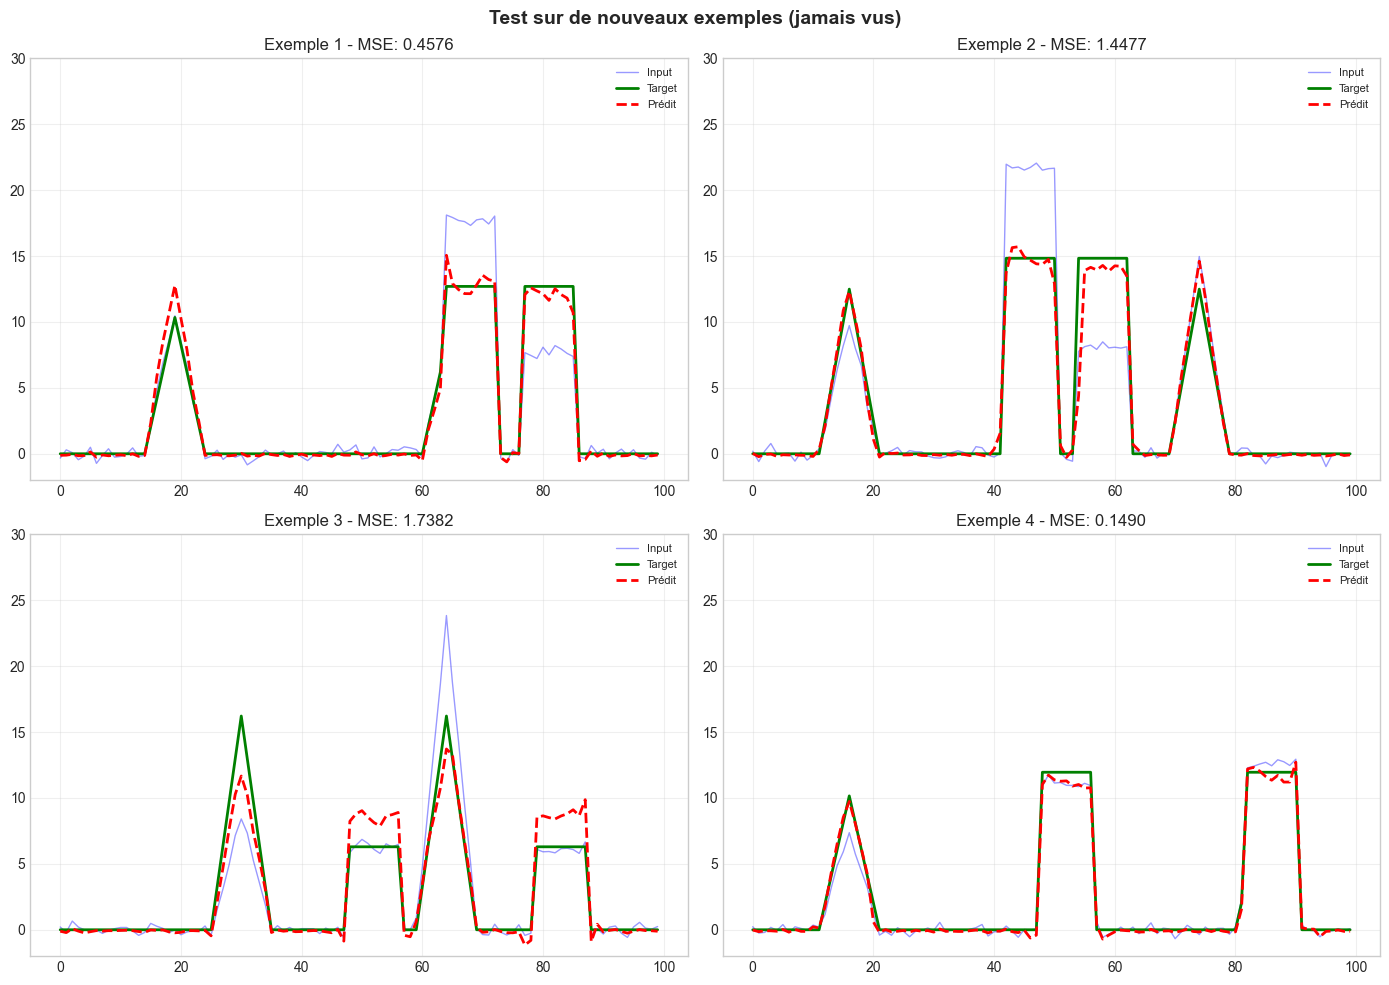

In [13]:
# Test sur 4 exemples du dataset de validation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model.eval()
for i, ax in enumerate(axes.flat):
    input_sig, target_sig, info = val_dataset[i]
    
    with torch.no_grad():
        pred = model(input_sig.unsqueeze(0).to(device)).squeeze(0).cpu()
    
    x = np.arange(len(input_sig))
    
    ax.plot(x, input_sig.numpy(), 'b-', alpha=0.4, label='Input', linewidth=1)
    ax.plot(x, target_sig.numpy(), 'g-', label='Target', linewidth=2)
    ax.plot(x, pred.numpy(), 'r--', label='Prédit', linewidth=2)
    
    mse = ((pred - target_sig) ** 2).mean().item()
    ax.set_title(f'Exemple {i+1} - MSE: {mse:.4f}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-2, 30)

plt.suptitle('Test sur de nouveaux exemples (jamais vus)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Étape 6: Comprendre l'Attention

### Comment le modèle "regarde" le signal?

attn_pattern.shape = (20, 20)


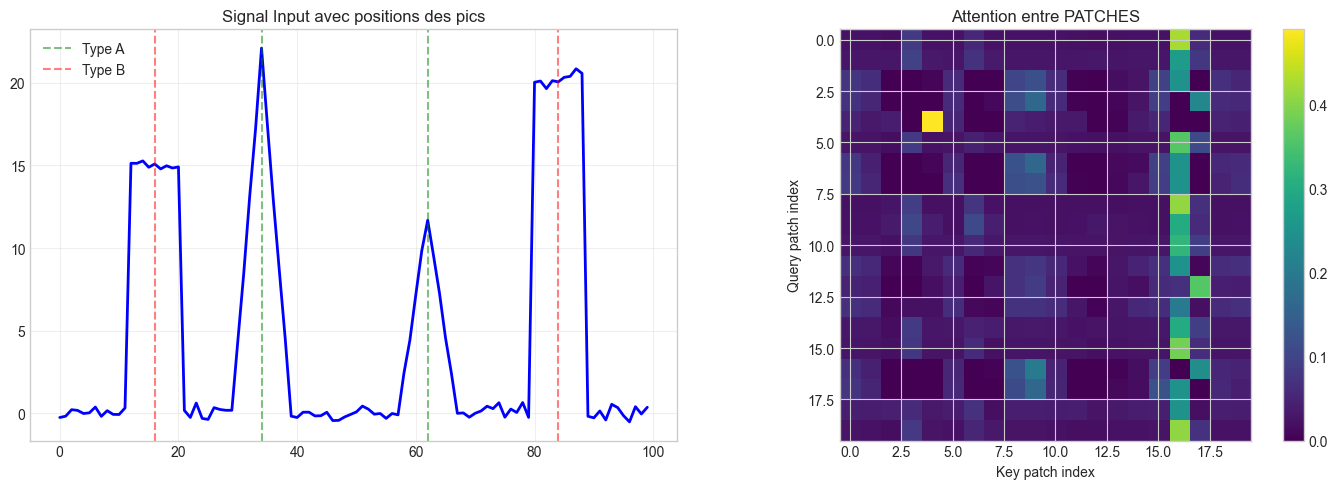

In [14]:
# === Visualisation de l'attention entre PATCHES ===

def get_attention_pattern_patches(model, signal, device):
    """Calcule les patterns de self-attention entre PATCHES.
    Retourne une matrice [num_patches, num_patches].
    """
    model.eval()
    with torch.no_grad():
        # 1) [seq_len] -> [1, seq_len]
        x = signal.unsqueeze(0).to(device)  # [1, 100]

        # 2) Découper en patches comme dans le forward du modèle
        x = x.view(1, model.num_patches, model.patch_size)  # [1, 20, 5]

        # 3) Projection + position
        x = model.input_proj(x)              # [1, 20, 64]
        x = x + model.pos_embedding          # [1, 20, 64]

        # 4) Récupérer les poids d'attention de la première couche de l'encoder
        layer0 = model.encoder.layers[0]
        attn_out, attn_weights = layer0.self_attn(
            x, x, x, need_weights=True
        )

        # Conversion en numpy et normalisation des dimensions
        attn_np = attn_weights.cpu().numpy()

        # Cas 3D: [batch, L, L] ou [L, batch, L]
        if attn_np.ndim == 3:
            if attn_np.shape[0] == 1:
                attn_np = attn_np[0]
            elif attn_np.shape[1] == 1:
                attn_np = attn_np[:, 0, :]

        # Si on a encore un vecteur, on le remet en matrice carrée
        if attn_np.ndim == 1:
            n = model.num_patches
            attn_np = attn_np.reshape(n, n)

    return attn_np  # [num_patches, num_patches]

# Utiliser un autre exemple du dataset (change l'index pour voir d'autres signaux)
example_idx = 3  # 0, 1, 2, ... selon ce que tu veux explorer
input_signal, output_signal, peak_info = dataset[example_idx]

# Utilisation sur un exemple (reprend input_signal, peak_info déjà définis plus haut)
attn_pattern = get_attention_pattern_patches(model, input_signal, device)
print("attn_pattern.shape =", attn_pattern.shape)  # vérification rapide

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Signal
ax1 = axes[0]
ax1.plot(input_signal.numpy(), 'b-', linewidth=2)
for pos in peak_info['type_a_positions']:
    ax1.axvline(x=pos, color='green', linestyle='--', alpha=0.5,
                label='Type A' if pos == peak_info['type_a_positions'][0] else '')
for pos in peak_info['type_b_positions']:
    ax1.axvline(x=pos, color='red', linestyle='--', alpha=0.5,
                label='Type B' if pos == peak_info['type_b_positions'][0] else '')
ax1.set_title('Signal Input avec positions des pics')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Matrice d'attention (entre patches)
ax2 = axes[1]
im = ax2.imshow(attn_pattern, cmap='viridis', aspect='equal')
ax2.set_title('Attention entre PATCHES')
ax2.set_xlabel('Key patch index')
ax2.set_ylabel('Query patch index')
fig.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

---
##  Résumé et Conclusions

### Ce que nous avons appris:

In [15]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    RÉSUMÉ                                            ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║   TÂCHE: Transformer des signaux avec pics                           ║
║     Input: Signal avec pics de hauteurs différentes                  ║
║     Output: Signal avec pics moyennés par type                       ║
║                                                                      ║
║   MODÈLE: Transformer Encoder-Only                                   ║
║     - Input projection (1 → 64 dimensions)                           ║
║     - Positional encoding                                            ║
║     - 3 couches d'Encoder (Self-Attention + FFN)                     ║
║     - Output projection (64 → 1 dimension)                           ║
║                                                                      ║
║   ENTRAÎNEMENT:                                                      ║
║     - Loss: MSE (Mean Squared Error)                                 ║
║     - Optimizer: AdamW                                               ║
║     - 30 epochs                                                      ║
║                                                                      ║
║   RÉSULTATS:                                                         ║
║     - Le modèle apprend à identifier les pics                        ║
║     - Il apprend à calculer les moyennes par type                    ║
║     - Réduction de loss significative                                ║
║                                                                      ║
║   CONCEPTS CLÉS:                                                     ║
║     - Self-Attention: Chaque position peut voir toutes les autres    ║
║     - Le modèle apprend SANS être explicitement programmé            ║
║     - C'est la puissance de l'apprentissage automatique!             ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                    RÉSUMÉ                                            ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║   TÂCHE: Transformer des signaux avec pics                           ║
║     Input: Signal avec pics de hauteurs différentes                  ║
║     Output: Signal avec pics moyennés par type                       ║
║                                                                      ║
║   MODÈLE: Transformer Encoder-Only                                   ║
║     - Input projection (1 → 64 dimensions)                           ║
║     - Positional encoding                                            ║
║     - 3 couches d'Encoder (Self-Attention + FFN)                     ║
║     - Output projection (64 → 1 dimension)                           ║
║                                                 

---
##  Pour aller plus loin

Essayez de modifier les paramètres:
- `num_layers`: Plus de couches = modèle plus puissant
- `num_heads`: Plus de têtes = plus de "points de vue"
- `d_model`: Plus de dimensions = plus de capacité
- `num_epochs`: Plus d'epochs = meilleur apprentissage

Commandes utiles:
```bash
# Exécuter l'exemple complet
python -m src.examples.toy_seq2seq

# Guide d'entraînement interactif
python -m docs.training_explained

# Visualisation de l'apprentissage
python -m docs.visualize_learning

# Tests unitaires
pytest tests/test_toy_seq2seq.py -v
```